# When a tune does not reach its target: read the convergence

A tune can fail for two quite different reasons, and telling them apart is the whole job:

- the target is genuinely out of reach for that variable, or
- a solution exists but the search did not find it.

They look identical from the outside — `cav.tuned` is `None` either way — and they need
opposite responses. The first is a design problem; the second is a starting-point problem.
The tuner gives you what you need to tell them apart: it reports the frequency range it
actually sampled, and it writes the convergence history to disk *even on failure*.

This example takes a C3795 end cell with its iris widened to 80 mm and asks it to resonate
at the 801.58 MHz design frequency by varying the cell half-length `L`. The tune fails —
and the reason turns out to be the second one, which the convergence and a short sweep make
plain.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.printing import set_verbose
from cavsim2d.utils.style import apply_style, WARM

set_verbose(False)
apply_style()

F = 801.58                                                   # design frequency [MHz]
# C3795 end-cell dimensions: A, B, a, b, Ri, L, Req [mm], iris widened to Ri = 80
END = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]


def tune_L(L0, var='L', cell='end-cell'):
    '''Tune the end-cell model to F, starting from half-length L0.'''
    cell_params = END[:5] + [float(L0), END[6]]
    study = Study(os.path.join(tempfile.mkdtemp(), 'c3795_ri80'))
    study.add_cavity([EllipticalCavity(1, cell_params, cell_params, cell_params,
                                       beampipe='left', name='C3795')], ['C3795'])
    study.run_tune({'freqs': F, 'processes': 1, 'tol': 1e-3,
                    'cell_type': {cell: var},
                    'eigenmode_config': {'processes': 1,
                                         'boundary_conditions': 'mm'}})
    return study.cavities_list[0]

## 1. The tune fails

Started from the nominal half-length, the search does not get there. `cav.tuned` comes back
`None`, and the message reports the range of frequencies it managed to sample.

In [2]:
cav = tune_L(END[5])
print('tuned?  cav.tuned is', cav.tuned)

ERROR:: Tune aborted: Geometry degenerated 3 consecutive times at L_el~=1.85e+15. Target frequency may be unreachable.
ERROR:: Tune did not reach target 801.58 MHz. Best |diff| = 12.390 MHz at L_el=93.795. Achievable freq range (sampled): [813.970, 815.879] MHz. Target may be unreachable by varying L_el alone — consider adjusting other geometry parameters (e.g., Req).
ERROR:: Done Tuning Cavity C3795 [end-cell: L_el]: Failed
ERROR:: Tune stage produced no result for C3795: cell_type=end-cell var=L
ERROR:: Tune results not found. Please tune the cavity
tuned?  cav.tuned is None


C:\Users\Soske\anaconda3\envs\cavsim2d\Lib\site-packages\scipy\optimize\_root_scalar.py:305: RuntimeWarning: Tolerance of -3810047084181993.5 reached.
  r, sol = methodc(f, x0, args=args, fprime=None, fprime2=None,


## 2. Read the convergence, which is saved even on failure

The history is persisted whether or not the tune succeeds, so `cav.tune.convergence` and
`cav.tune.plot_convergence()` work here. The target is drawn as a dashed line. The
tell-tale is in the `L` panel: the half-length does not settle anywhere near the cavity's
own scale — it runs away entirely, while the frequency it reaches barely moves.

That combination — a variable diverging while the objective sits still — is the signature
of a search that has lost the root, not of a target that cannot be met.

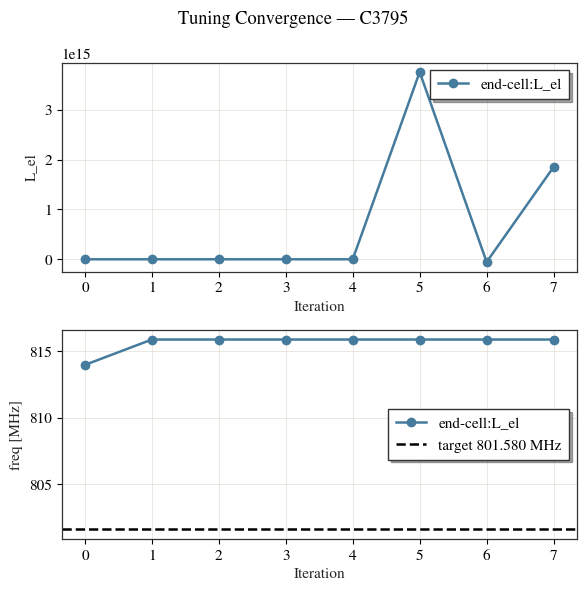

(<Figure size 600x600 with 2 Axes>,
 array([<Axes: xlabel='Iteration', ylabel='L_el'>,
        <Axes: xlabel='Iteration', ylabel='freq [MHz]'>], dtype=object))

In [3]:
cav.tune.plot_convergence()

In [4]:
conv = cav.tune.convergence
L_hist = conv[conv['parameter'] == 'L_el']['value'].astype(float)
f_hist = conv[conv['parameter'] == 'freq [MHz]']['value'].astype(float)
print('iterations       :', len(f_hist))
print('L range visited  : %.3g  ...  %.3g mm' % (L_hist.min(), L_hist.max()))
print('freq sampled     : %.3f ... %.3f MHz   (target %.2f)'
      % (f_hist.min(), f_hist.max(), F))

iterations       : 8
L range visited  : -5.46e+13  ...  3.76e+15 mm
freq sampled     : 813.970 ... 815.879 MHz   (target 801.58)


## 3. Why: the response is not monotonic

Sweep the cell's accelerating frequency against its half-length directly. The frequency
does not fall steadily with `L` as one might assume — it *rises* to a maximum near
`L = 120` mm and only then falls, very slowly.

That shape is what defeats the search. From the nominal start, the frequency has to come
down by about 12 MHz to reach the target. Locally, increasing `L` increases the frequency,
so the secant extrapolates in the other direction, towards larger `L` — where the curve
turns over and approaches the target so gradually that the extrapolation runs off to
absurd lengths. The root is real, but it lies on the *short* side of the start point,
just above `L = 80` mm, and an unbracketed search that steps the wrong way once never comes
back.

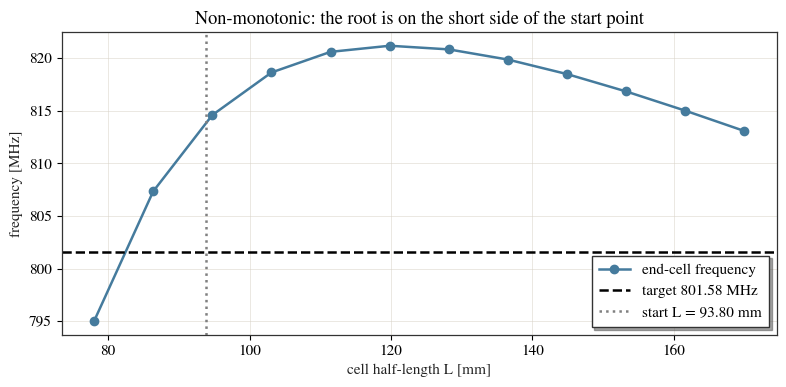

sampled range: [794.99, 821.19] MHz   target 801.58   maximum near L = 120 mm


In [5]:
def cell_freq(L):
    '''Accelerating frequency of the end-cell model at half-length L.'''
    cell = END[:5] + [float(L), END[6]]
    c = EllipticalCavity(1, cell, cell, cell, beampipe='left')
    if c.profile() is None:                      # degenerate geometry
        return np.nan
    c.set_workspace(tempfile.mkdtemp())
    try:
        c.eigenmode.run(mesh_config={'h': 20, 'p': 3}, n_modes=2,
                        boundary_conditions='mm')
        d = c.eigenmode.qois_df.query('m == 0')
        return float(d.loc[d['R/Q [Ohm]'].idxmax()]['freq [MHz]'])
    except Exception:
        return np.nan


Ls = np.linspace(78, 170, 12)
fs = np.array([cell_freq(L) for L in Ls])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(Ls, fs, 'o-', color=WARM[0], label='end-cell frequency')
ax.axhline(F, ls='--', color='k', label='target %.2f MHz' % F)
ax.axvline(END[5], ls=':', color='0.5', label='start L = %.2f mm' % END[5])
ax.set_xlabel('cell half-length L [mm]')
ax.set_ylabel('frequency [MHz]')
ax.set_title('Non-monotonic: the root is on the short side of the start point')
ax.legend()
plt.tight_layout()
plt.show()

print('sampled range: [%.2f, %.2f] MHz   target %.2f   maximum near L = %.0f mm'
      % (np.nanmin(fs), np.nanmax(fs), F, Ls[np.nanargmax(fs)]))

## 4. Two ways to fix it

### Start on the right side of the turning point

The sweep puts the root just above `L = 80` mm. Start the same tune there and it converges at
once — same cavity, same variable, same target.

In [6]:
cav_ok = tune_L(84.0)
print('tuned?', 'None' if cav_ok.tuned is None else 'yes')
if cav_ok.tuned is not None:
    print('L      : %.3f mm (started from 84.0)' % cav_ok.tuned.parameters['L_el'])
    print('freq   : %.4f MHz  (target %.2f)'
          % (cav_ok.tune.qois['end-cell']['FREQ'], F))

tuned? yes
L      : 80.640 mm (started from 84.0)
freq   : 801.5800 MHz  (target 801.58)


### Or use a variable whose response is monotonic

`L` is an awkward handle for this cell: it turns over, and it only moves the frequency by a
couple of MHz either side of the turning point. The equator radius moves it monotonically
and by roughly 5 MHz per millimetre, so the same target is reached from the nominal start
with no care at all.

Note which key that is. `Req` is the *shared* equator radius — one value for the whole
cavity rather than a per-cell one — so it lives in the `'mid-cell'` slot even on a single
cell. Asking for it as `{'end-cell': 'Req'}` addresses a value the geometry ignores, and
the tune then reports that the variable did not move the frequency at all.

In [7]:
cav_req = tune_L(END[5], var='Req', cell='mid-cell')
print('tuned?', 'None' if cav_req.tuned is None else 'yes')
print('Req    : %.3f mm (was %.3f)' % (cav_req.tuned.parameters['Req_m'], END[6]))
print('freq   : %.4f MHz  (target %.2f)'
      % (cav_req.tune.qois['mid-cell']['FREQ'], F))

tuned? yes
Req    : 175.888 mm (was 171.200)
freq   : 801.5802 MHz  (target 801.58)


## Reading it

- A tune that does not reach its target leaves `cav.tuned` as `None` rather than handing
  back a geometry that misses. Read the message: it names the frequency range the search
  actually sampled.
- Compare that range with your target. If the target lies inside it, a root exists and the
  search is the problem — start it closer, or bracket it. If the target lies well outside,
  the variable genuinely cannot get there and the design has to change.
- A range of essentially zero width is a third case: the variable is not reaching the
  geometry at all. The usual cause is a shared parameter addressed through a per-cell slot.
- The convergence is written on failure as well as on success, so
  `cav.tune.convergence` and `cav.tune.plot_convergence()` show what the search did. A tune
  variable running away while the objective barely moves means the search lost the root.
- Sweep the variable before trusting a tune that has misbehaved. A monotonic response is
  what an unbracketed root-finder assumes; this one turns over, and that is the whole
  explanation.

See [tuning to a frequency](tune_to_frequency.ipynb) for the straightforward case, and
[tuning to a figure of merit](qoi_targets.ipynb) for what changes once there is more than
one target — including a staged tune that reports a genuine no-solution.